<a href="https://colab.research.google.com/github/setugujar2-source/deepLearning-Projects/blob/main/IGBT_Temp_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# 1. 设置随机种子
np.random.seed(42)
n_samples = 10000  # 造 2000 条数据

# 2. 生成特征（物理量）
Vce = np.random.uniform(1.0, 2.5, n_samples)   # 饱和压降 1.0~2.5V
Ic = np.random.uniform(10, 150, n_samples)     # 导通电流 10~150A
theta_c = np.random.uniform(25, 80, n_samples) # 壳温 25~80度

# 3. 生成标签（结温），模拟真实物理关系（结温 > 壳温，且受功率影响）
# 3. 生成标签（结温）
theta_j = theta_c + (Vce * Ic) * 0.05 + np.random.normal(0, 1.5, n_samples)

# 4. 组合成数据集（注意：这里加入了第四个特征 Power）
Power = Vce * Ic  # <--- 新增这一行
X = np.column_stack((Vce, Ic, theta_c, Power))
y = theta_j.reshape(-1, 1) # <--- 改为4个特征

# 5. 划分训练集和测试集
# 5. 划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. 数据归一化（神经网络对数值范围很敏感，务必把数据缩放到 0~1 之间）
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 7. 转换为 CNN 需要的输入形状 (步长, 通道数) = (4, 1)
X_train_cnn = X_train_scaled.reshape(-1, 4, 1)
X_test_cnn = X_test_scaled.reshape(-1, 4, 1)

print(f"训练集形状: {X_train_cnn.shape}, 测试集形状: {X_test_cnn.shape}")

训练集形状: (8000, 4, 1), 测试集形状: (2000, 4, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# 1. 数据归一化（神经网络对数值范围很敏感，务必把数据缩放到 0~1 之间）
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 2. 一维CNN需要输入形状为 (步长, 通道数) = (3, 1)
X_train_cnn = X_train_scaled.reshape(-1, 4, 1)
X_test_cnn = X_test_scaled.reshape(-1, 4, 1)

# 3. 搭建一维 CNN 模型

def build_regression_model():
    model = Sequential()
    model.add(Flatten(input_shape=(4, 1)))
    # 极简：直接展平到输出，相当于一个线性回归，没有任何隐藏层！
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
    return model
model = build_regression_model()
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 训练模型
history = model.fit(X_train_cnn, y_train_scaled,
                    validation_data=(X_test_cnn, y_test_scaled),
                    epochs=50, batch_size=32, verbose=1)

# 预测并反归一化（还原到真实温度）
y_pred_scaled = model.predict(X_test_cnn)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled)

# 计算平均绝对误差（MAE）
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_true, y_pred)
print(f"\n结温预测的平均绝对误差 (MAE): {mae:.2f} 摄氏度")

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # 监控验证集损失
    patience=3,             # 连续3轮没进步就停
    restore_best_weights=True # 恢复最佳权重
)

history = model.fit(
    X_train_cnn, y_train_scaled,
    validation_data=(X_test_cnn, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],  # 加上早停
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0574 - mae: 0.1602 - val_loss: 0.0018 - val_mae: 0.0342
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1191e-04 - mae: 0.0210 - val_loss: 5.0242e-04 - val_mae: 0.0178
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9693e-04 - mae: 0.0178 - val_loss: 4.8652e-04 - val_mae: 0.0175
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8060e-04 - mae: 0.0175 - val_loss: 4.7972e-04 - val_mae: 0.0174
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.6766e-04 - mae: 0.0172 - val_loss: 4.6213e-04 - val_mae: 0.0171
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5976e-04 - mae: 0.0171 - val_loss: 4.5953e-04 - val_mae: 0.0171
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5011e-04 - mae: 0.0169 - val_loss: 4.5033e-04 - val_mae: 0.0169
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.4960e-04 - mae: 0.0169 - val_loss: 4.5136e-04 - val_mae: 0.0169


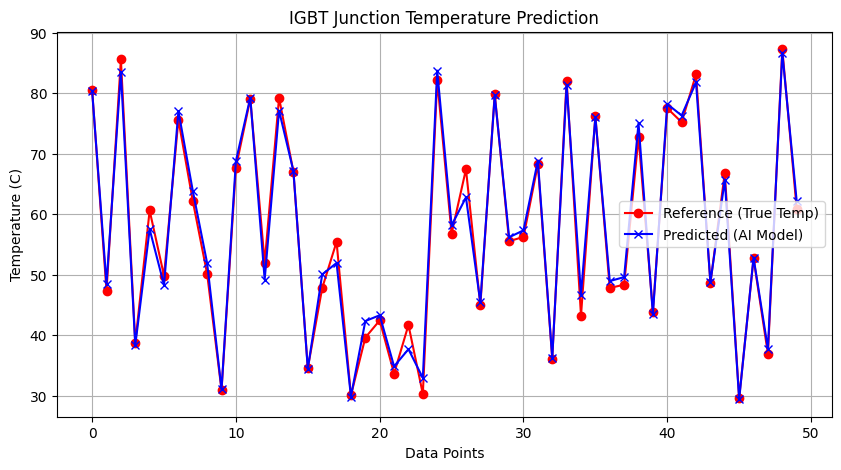

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_true[:50], label='Reference (True Temp)', color='red', marker='o')
plt.plot(y_pred[:50], label='Predicted (AI Model)', color='blue', marker='x')
plt.title('IGBT Junction Temperature Prediction')
plt.xlabel('Data Points')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()